In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv('CCRB-Complaint-Data_202007271729/allegations_202007271729.csv')
df.head()

,unique_mos_id,first_name,last_name,command_now,shield_no,complaint_id,month_received,year_received,month_closed,year_closed,...,mos_age_incident,complainant_ethnicity,complainant_gender,complainant_age_incident,fado_type,allegation,precinct,contact_reason,outcome_description,board_disposition
0,10004,Jonathan,Ruiz,078 PCT,8409,42835,7,2019,5,2020,...,32,Black,Female,38.0,Abuse of Authority,Failure to provide RTKA card,78.0,Report-domestic dispute,No arrest made or summons issued,Substantiated (Command Lvl Instructions)
1,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,...,24,Black,Male,26.0,Discourtesy,Action,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges)
2,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,...,24,Black,Male,26.0,Offensive Language,Race,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges)
3,10007,John,Sears,078 PCT,5952,26146,7,2012,9,2013,...,25,Black,Male,45.0,Abuse of Authority,Question,67.0,PD suspected C/V of violation/crime - street,No arrest made or summons issued,Substantiated (Charges)
4,10009,Noemi,Sierra,078 PCT,24058,40253,8,2018,2,2019,...,39,NaN,NaN,16.0,Force,Physical force,67.0,Report-dispute,Arrest - other violation/crime,Substantiated (Command Discipline A)


In [20]:
serious_discipline = [
    'Substantiated (Charges)',
    'Substantiated (CCRB Rec. DOE)',
    'Substantiated (CCRB Rec. Hrd)',
    'Substantiated (CCRB Rec. HOD)'
]

df['consequence'] = df['board_disposition'].apply(lambda x: 
    'Serious' if x in serious_discipline else 'No Serious Discipline')

serious = len(df[df['consequence'] == 'Serious'])
no_serious = len(df[df['consequence'] == 'No Serious Discipline'])
print(serious)
print(no_serious)

3796
29562


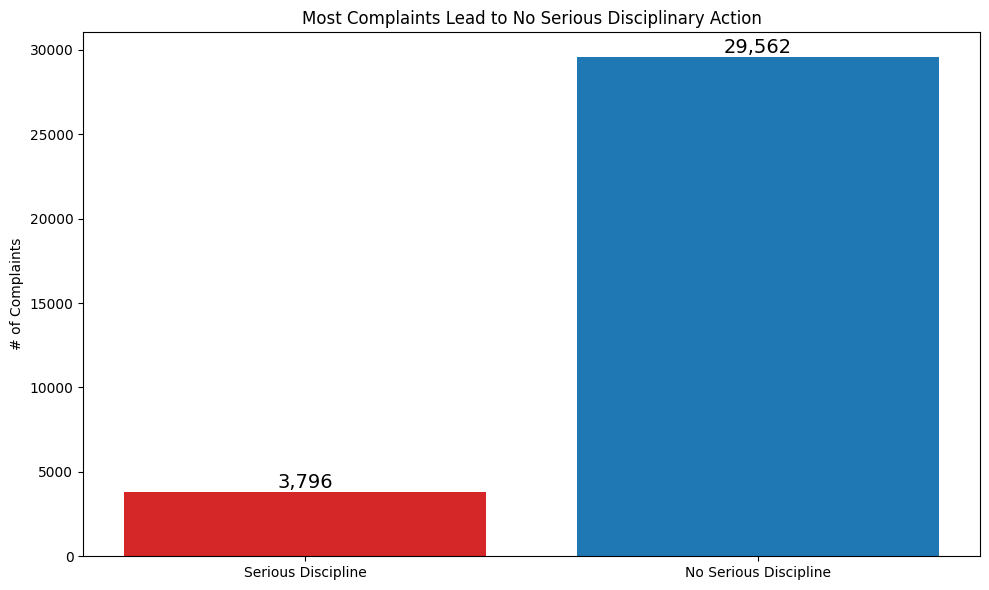

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(['Serious Discipline', 'No Serious Discipline'], 
       [serious, no_serious], 
       color=['#d62728', '#1f77b4'])

ax.set_ylabel('# of Complaints')
ax.set_title('Most Complaints Lead to No Serious Disciplinary Action')

for i, count in enumerate([serious, no_serious]):
    ax.text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=14)
plt.tight_layout()
plt.show()

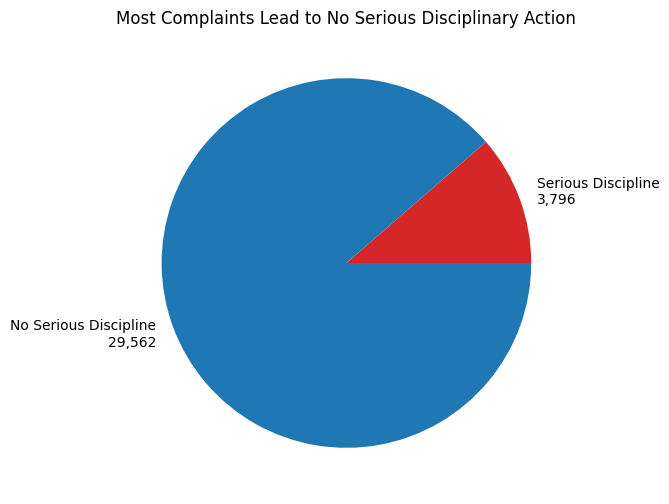

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.pie(
    [serious, no_serious],
    labels=[f'Serious Discipline\n{serious:,}', f'No Serious Discipline\n{no_serious:,}'],
    colors=['#d62728', '#1f77b4']
)

plt.title('Most Complaints Lead to No Serious Disciplinary Action')
plt.show()
